In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
a = pd.read_csv('dim_date.csv')
b = pd.read_csv('/content/electric_vehicle_sales_by_makers.csv')
c= pd.read_csv('/content/electric_vehicle_sales_by_state.csv')

In [ ]:
a.shape


(36, 3)

In [ ]:
a.head()

,date,fiscal_year,quarter
0,01-Apr-21,2022,Q1
1,01-May-21,2022,Q1
2,01-Jun-21,2022,Q1
3,01-Jul-21,2022,Q2
4,01-Aug-21,2022,Q2


In [ ]:
b.shape


(816, 4)

In [ ]:
b.head()

,date,vehicle_category,maker,electric_vehicles_sold
0,01-Apr-21,2-Wheelers,OLA ELECTRIC,0
1,01-Apr-22,2-Wheelers,OKAYA EV,0
2,01-May-21,2-Wheelers,OLA ELECTRIC,0
3,01-Jun-21,2-Wheelers,OLA ELECTRIC,0
4,01-Jul-21,2-Wheelers,OLA ELECTRIC,0


In [ ]:
c.shape

(2445, 5)

In [ ]:
c.head()

,date,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold
0,01-Apr-21,Sikkim,2-Wheelers,0,398
1,01-Apr-21,Sikkim,4-Wheelers,0,361
2,01-May-21,Sikkim,2-Wheelers,0,113
3,01-May-21,Sikkim,4-Wheelers,0,98
4,01-Jun-21,Sikkim,2-Wheelers,0,229


check dublicates


In [ ]:
b.duplicated ().sum()


np.int64(0)

In [ ]:
c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    2445 non-null   object
 1   state                   2445 non-null   object
 2   vehicle_category        2445 non-null   object
 3   electric_vehicles_sold  2445 non-null   int64 
 4   total_vehicles_sold     2445 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 95.6+ KB


In [ ]:
c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    2445 non-null   object
 1   state                   2445 non-null   object
 2   vehicle_category        2445 non-null   object
 3   electric_vehicles_sold  2445 non-null   int64 
 4   total_vehicles_sold     2445 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 95.6+ KB


In [ ]:
df = c.merge(b, on='date', how='left')
df = df.merge(a, on='date', how='left')

In [ ]:
df.head()

,date,state,vehicle_category_x,electric_vehicles_sold_x,total_vehicles_sold,vehicle_category_y,maker,electric_vehicles_sold_y,fiscal_year,quarter
0,01-Apr-21,Sikkim,2-Wheelers,0,398,2-Wheelers,OLA ELECTRIC,0,2022,Q1
1,01-Apr-21,Sikkim,2-Wheelers,0,398,4-Wheelers,BYD India,0,2022,Q1
2,01-Apr-21,Sikkim,2-Wheelers,0,398,4-Wheelers,PCA Automobiles,0,2022,Q1
3,01-Apr-21,Sikkim,2-Wheelers,0,398,4-Wheelers,BMW India,0,2022,Q1
4,01-Apr-21,Sikkim,2-Wheelers,0,398,4-Wheelers,Volvo Auto India,0,2022,Q1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55420 entries, 0 to 55419
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   date                      55420 non-null  object
 1   state                     55420 non-null  object
 2   vehicle_category_x        55420 non-null  object
 3   electric_vehicles_sold_x  55420 non-null  int64 
 4   total_vehicles_sold       55420 non-null  int64 
 5   vehicle_category_y        55420 non-null  object
 6   maker                     55420 non-null  object
 7   electric_vehicles_sold_y  55420 non-null  int64 
 8   fiscal_year               55420 non-null  int64 
 9   quarter                   55420 non-null  object
dtypes: int64(4), object(6)
memory usage: 4.2+ MB


###1. List the top 3 and bottom 3 makers for the fiscal years 2023 and 2024 in terms of the number of 2-wheelers sold.

In [ ]:
print('Top 3 2-Wheeler Makers for Fiscal Year 2023:')
print(maker_sales.loc[2023].nlargest(3))

print('\nBottom 3 2-Wheeler Makers for Fiscal Year 2023:')
print(maker_sales.loc[2023].nsmallest(3))

print('\nTop 3 2-Wheeler Makers for Fiscal Year 2024:')
print(maker_sales.loc[2024].nlargest(3))

print('\nBottom 3 2-Wheeler Makers for Fiscal Year 2024:')
print(maker_sales.loc[2024].nsmallest(3))

Top 3 2-Wheeler Makers for Fiscal Year 2023:
maker
OLA ELECTRIC     5187822
OKINAWA          3296130
HERO ELECTRIC    3025762
Name: electric_vehicles_sold_y, dtype: int64

Bottom 3 2-Wheeler Makers for Fiscal Year 2023:
maker
Mercedes -Benz AG    2414
Volvo Auto India     3570
PCA Automobiles      5134
Name: electric_vehicles_sold_y, dtype: int64

Top 3 2-Wheeler Makers for Fiscal Year 2024:
maker
OLA ELECTRIC    10919996
TVS              6119104
ATHER            3639756
Name: electric_vehicles_sold_y, dtype: int64

Bottom 3 2-Wheeler Makers for Fiscal Year 2024:
maker
Mercedes -Benz AG     9863
KIA Motors           11126
Volvo Auto India     15567
Name: electric_vehicles_sold_y, dtype: int64


###2.  Identify the top 5 states with the highest penetration rate in 2-wheeler and 4-wheeler EV sales in FY 2024.

In [ ]:
# Filter for FY 2024
df_2024 = df[df['fiscal_year'] == 2024]

# Group by state and vehicle category and sum sales
state_sales_2024 = df_2024.groupby(['state', 'vehicle_category_x']).agg(
    electric_vehicles_sold_x=('electric_vehicles_sold_x', 'sum'),
    total_vehicles_sold=('total_vehicles_sold', 'sum')
).reset_index()

# Calculate penetration rate, handling division by zero
state_sales_2024['penetration_rate'] = (
    state_sales_2024['electric_vehicles_sold_x'] / state_sales_2024['total_vehicles_sold']
).fillna(0) * 100

# Filter for 2-wheelers and get top 5
top_5_2wheelers = state_sales_2024[
    state_sales_2024['vehicle_category_x'] == '2-Wheelers'
].nlargest(5, 'penetration_rate')

# Filter for 4-wheelers and get top 5
top_5_4wheelers = state_sales_2024[
    state_sales_2024['vehicle_category_x'] == '4-Wheelers'
].nlargest(5, 'penetration_rate')

print('Top 5 states with highest 2-wheeler EV penetration rate in FY 2024:')
print(top_5_2wheelers[['state', 'penetration_rate']])

print('\nTop 5 states with highest 4-wheeler EV penetration rate in FY 2024:')
print(top_5_4wheelers[['state', 'penetration_rate']])

Top 5 states with highest 2-wheeler EV penetration rate in FY 2024:
          state  penetration_rate
20          Goa         17.992264
34       Kerala         13.524903
32    Karnataka         11.573279
40  Maharashtra         10.072507
18        Delhi          9.400866

Top 5 states with highest 4-wheeler EV penetration rate in FY 2024:
         state  penetration_rate
35      Kerala          5.758445
13  Chandigarh          4.503112
19       Delhi          4.290757
33   Karnataka          4.261120
21         Goa          4.254353


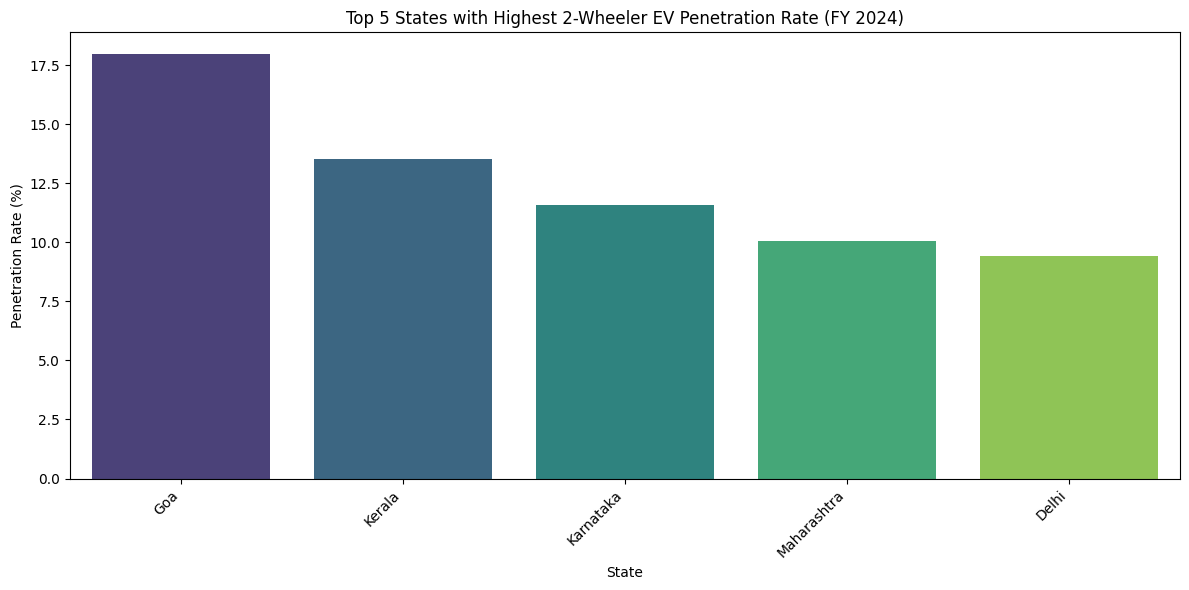

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='state', y='penetration_rate', data=top_5_2wheelers, palette='viridis', hue='state', legend=False)
plt.title('Top 5 States with Highest 2-Wheeler EV Penetration Rate (FY 2024)')
plt.xlabel('State')
plt.ylabel('Penetration Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

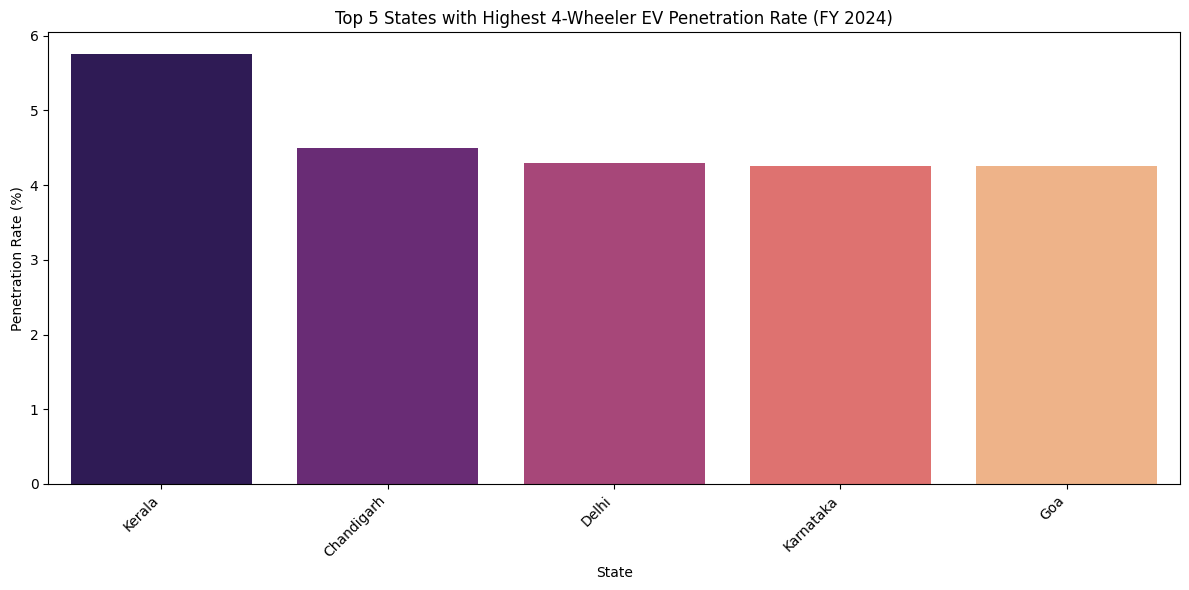

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='state', y='penetration_rate', data=top_5_4wheelers, palette='magma', hue='state', legend=False)
plt.title('Top 5 States with Highest 4-Wheeler EV Penetration Rate (FY 2024)')
plt.xlabel('State')
plt.ylabel('Penetration Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###3. List the states with negative penetration (decline) in EV sales from 2022 to 2024?

In [ ]:
negative = state_sales_2024[state_sales_2024['penetration_rate'] < 0].nsmallest(5, 'penetration_rate')

In [ ]:
negative

,state,vehicle_category_x,electric_vehicles_sold_x,total_vehicles_sold,penetration_rate


In [ ]:
# Filter for FY 2022 and FY 2024
df_filtered = df[df['fiscal_year'].isin([2022, 2024])]

# Group by state, fiscal_year, and vehicle_category to get totals
state_penetration = df_filtered.groupby(['state', 'fiscal_year', 'vehicle_category_x']).agg(
    ev_sold=('electric_vehicles_sold_x', 'sum'),
    total_sold=('total_vehicles_sold', 'sum')
).reset_index()

# Calculate penetration rate
state_penetration['penetration_rate'] = (state_penetration['ev_sold'] / state_penetration['total_sold']) * 100

# Pivot to compare 2022 vs 2024
comparison_df = state_penetration.pivot_table(
    index=['state', 'vehicle_category_x'],
    columns='fiscal_year',
    values='penetration_rate'
).reset_index()

# Calculate the change (decline)
comparison_df['decline'] = comparison_df[2024] - comparison_df[2022]

# Filter for states where decline is negative
negative_growth_states = comparison_df[comparison_df['decline'] < 0].sort_values(by='decline')

print("States with declining EV penetration (2022 to 2024):")
display(negative_growth_states[['state', 'vehicle_category_x', 2022, 2024, 'decline']])

States with declining EV penetration (2022 to 2024):


fiscal_year,state,vehicle_category_x,2022,2024,decline
3,Andaman & Nicobar Island,4-Wheelers,1.881950,0.844119,-1.037831
36,Ladakh,2-Wheelers,4.477612,4.062910,-0.414702


###4. What are the quarterly trends based on sales volume for the top 5 EV makers (4-wheelers) from 2022 to 2024?

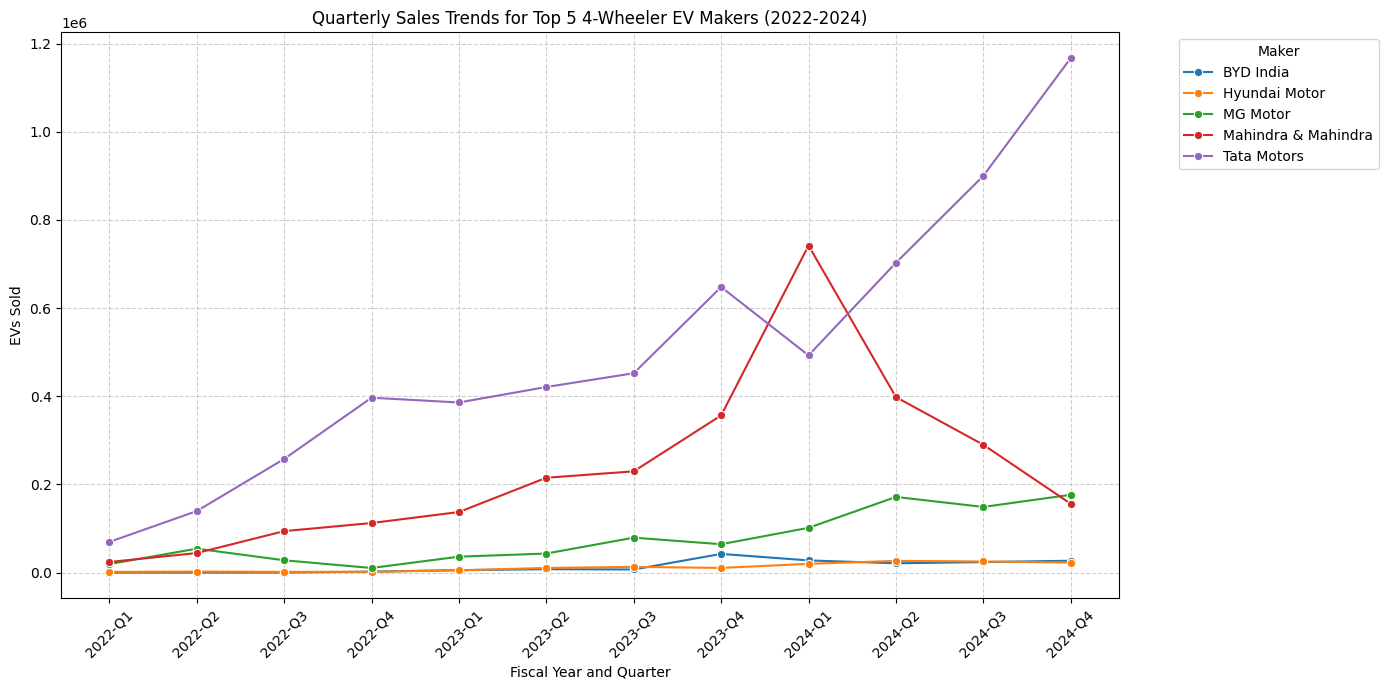

In [ ]:
# 1. Identify the top 5 4-wheeler makers by total sales (2022-2024)
top_5_makers_4w = df[df['vehicle_category_y'] == '4-Wheelers'].groupby('maker')['electric_vehicles_sold_y'].sum().nlargest(5).index.tolist()

# 2. Filter data for these top 5 makers
df_top_5_4w = df[df['maker'].isin(top_5_makers_4w)]

# 3. Group by maker, fiscal_year, and quarter to get quarterly sales volume
# We use 'electric_vehicles_sold_y' because it represents the maker's sales
quarterly_trends = df_top_5_4w.groupby(['maker', 'fiscal_year', 'quarter'])['electric_vehicles_sold_y'].sum().reset_index()

# 4. Create a combined 'Period' column for better x-axis representation
quarterly_trends['period'] = quarterly_trends['fiscal_year'].astype(str) + "-" + quarterly_trends['quarter']
quarterly_trends = quarterly_trends.sort_values(['fiscal_year', 'quarter'])

# 5. Plot the trends
plt.figure(figsize=(14, 7))
sns.lineplot(data=quarterly_trends, x='period', y='electric_vehicles_sold_y', hue='maker', marker='o')

plt.title('Quarterly Sales Trends for Top 5 4-Wheeler EV Makers (2022-2024)')
plt.xlabel('Fiscal Year and Quarter')
plt.ylabel('EVs Sold')
plt.legend(title='Maker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###5.How do the EV sales and penetration rates in Delhi compare to Karnataka for 2024?

Comparison of Delhi and Karnataka (FY 2024):


electric_vehicles_sold_x            penetration_rate  \
vehicle_category_x               2-Wheelers 4-Wheelers       2-Wheelers   
state                                                                     
Delhi                              876162.0   198490.0         9.400866   
Karnataka                         3406553.0   296194.0        11.573279   

                               
vehicle_category_x 4-Wheelers  
state                          
Delhi                4.290757  
Karnataka            4.261120

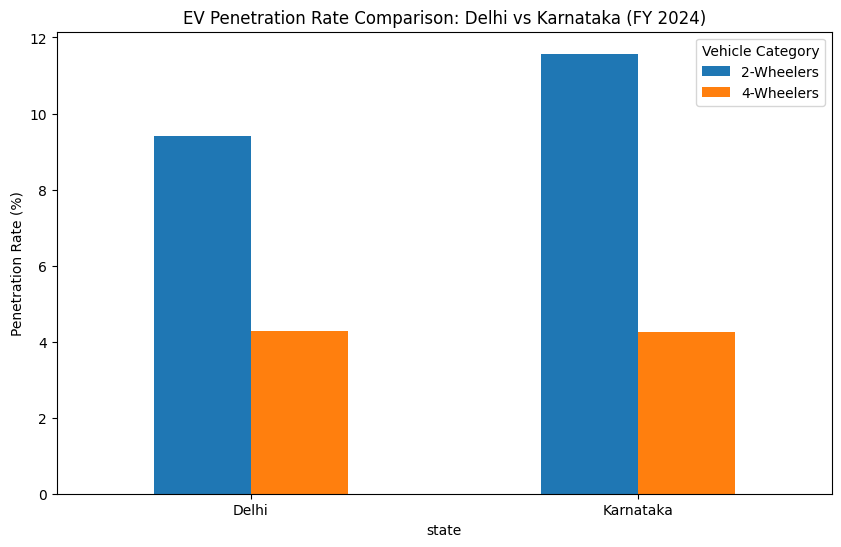

In [ ]:
import pandas as pd

# Filter for Delhi and Karnataka from our 2024 state analysis
comparison_states = state_sales_2024[state_sales_2024['state'].isin(['Delhi', 'Karnataka'])]

# Pivot for better side-by-side comparison
comparison_table = comparison_states.pivot(index='state', columns='vehicle_category_x', values=['electric_vehicles_sold_x', 'penetration_rate'])

print('Comparison of Delhi and Karnataka (FY 2024):')
display(comparison_table)

# Quick Visualization
comparison_states.pivot(index='state', columns='vehicle_category_x', values='penetration_rate').plot(kind='bar', figsize=(10, 6))
plt.title('EV Penetration Rate Comparison: Delhi vs Karnataka (FY 2024)')
plt.ylabel('Penetration Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Vehicle Category')
plt.show()

### 6. CAGR in 4-wheeler units for top 5 makers (2022 to 2024)
Formula: $CAGR = [(Ending Value / Beginning Value)^{1/n}] - 1$

In [ ]:
maker_4w_yearly = df[df['maker'].isin(top_5_makers_4w) & (df['vehicle_category_y'] == '4-Wheelers')].groupby(['maker', 'fiscal_year'])['electric_vehicles_sold_y'].sum().unstack()

# CAGR formula: (Vfinal/Vinitial)^(1/t) - 1. Here t = 2024 - 2022 = 2 years
maker_4w_yearly['CAGR'] = ((maker_4w_yearly[2024] / maker_4w_yearly[2022])**(1/2) - 1) * 100

print("CAGR for Top 5 4-Wheeler Makers (2022-2024):")
display(maker_4w_yearly[['CAGR']].sort_values(by='CAGR', ascending=False))

CAGR for Top 5 4-Wheeler Makers (2022-2024):


fiscal_year,CAGR
maker,
BYD India,565.565043
Hyundai Motor,255.277669
Mahindra & Mahindra,140.269185
MG Motor,131.321577
Tata Motors,94.386298


### 7. Top 10 states with highest CAGR in total vehicles sold (2022-2024)

In [ ]:
state_total_yearly = df.groupby(['state', 'fiscal_year'])['total_vehicles_sold'].sum().unstack()
# Removing states with missing data in 2022 or 2024
state_total_yearly = state_total_yearly.dropna(subset=[2022, 2024])
state_total_yearly['CAGR'] = ((state_total_yearly[2024] / state_total_yearly[2022])**(1/2) - 1) * 100

print("Top 10 States by Total Vehicle Sales CAGR:")
display(state_total_yearly[['CAGR']].nlargest(10, 'CAGR'))

Top 10 States by Total Vehicle Sales CAGR:


fiscal_year,CAGR
state,
Meghalaya,31.356381
Goa,30.273704
Karnataka,28.099295
Delhi,25.646138
Rajasthan,24.227999
Gujarat,23.254907
Assam,22.833642
Mizoram,21.440957
Arunachal Pradesh,20.962193


### 8. Peak and Low Season Months for EV Sales (2022-2024)

/tmp/ipykernel_1435/1325098929.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['date']).dt.strftime('%B')


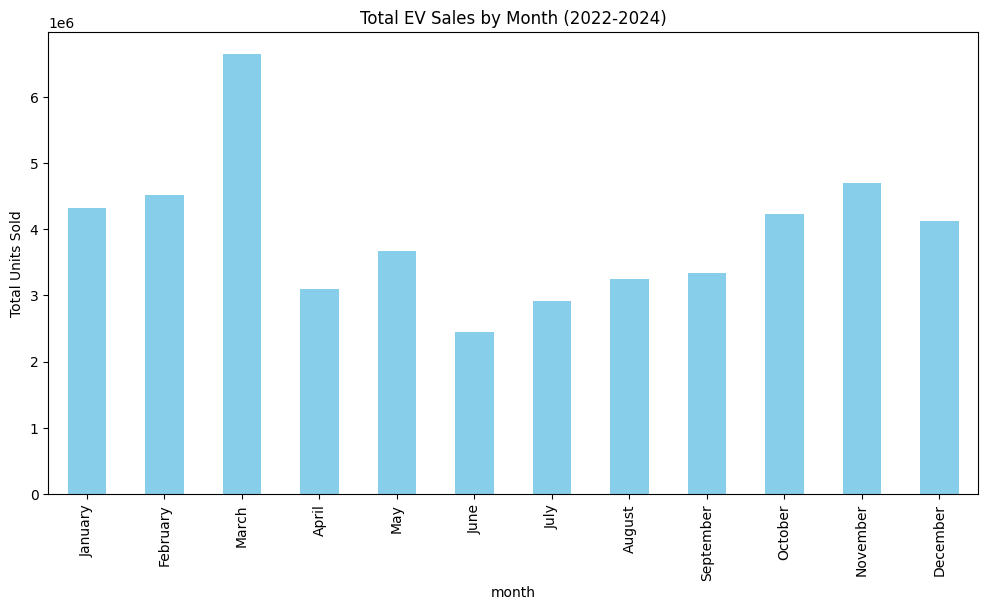

Peak Month: March (6648383 units)
Low Month: June (2448820 units)


In [ ]:
df['month'] = pd.to_datetime(df['date']).dt.strftime('%B')
monthly_sales = df.groupby('month')['electric_vehicles_sold_x'].sum().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Total EV Sales by Month (2022-2024)')
plt.ylabel('Total Units Sold')
plt.show()

print(f"Peak Month: {monthly_sales.idxmax()} ({monthly_sales.max()} units)")
print(f"Low Month: {monthly_sales.idxmin()} ({monthly_sales.min()} units)")

### 9. Projected EV Sales for Top 10 States in 2030
Based on state-specific EV sales CAGR from 2022 to 2024.

In [ ]:
state_ev_yearly = df.groupby(['state', 'fiscal_year'])['electric_vehicles_sold_x'].sum().unstack()
state_ev_yearly = state_ev_yearly.dropna(subset=[2022, 2024])
# Avoid division by zero
state_ev_yearly = state_ev_yearly[state_ev_yearly[2022] > 0]

state_ev_yearly['CAGR'] = ((state_ev_yearly[2024] / state_ev_yearly[2022])**(1/2) - 1)

# Project to 2030 (6 years from 2024)
state_ev_yearly['Projected_2030'] = state_ev_yearly[2024] * ((1 + state_ev_yearly['CAGR'])**6)

print("Top 10 States Projected EV Sales in 2030:")
display(state_ev_yearly[['Projected_2030']].nlargest(10, 'Projected_2030'))

Top 10 States Projected EV Sales in 2030:


fiscal_year,Projected_2030
state,
Maharashtra,3.508826e+08
Kerala,3.095754e+08
Uttar Pradesh,2.738320e+08
Gujarat,2.272327e+08
Karnataka,2.203250e+08
Chhattisgarh,1.870745e+08
Madhya Pradesh,1.849207e+08
Meghalaya,1.284902e+08
West Bengal,1.098128e+08


### 10. Estimated Revenue Growth Rate
Assumptions: Avg 2W Price = ₹85k, Avg 4W Price = ₹15L.

In [ ]:
price_2w = 85000
price_4w = 1500000

rev_df = df.groupby(['fiscal_year', 'vehicle_category_x'])['electric_vehicles_sold_x'].sum().unstack()
rev_df['Revenue'] = (rev_df['2-Wheelers'] * price_2w) + (rev_df['4-Wheelers'] * price_4w)

growth_22_24 = ((rev_df.loc[2024, 'Revenue'] / rev_df.loc[2022, 'Revenue']) - 1) * 100
growth_23_24 = ((rev_df.loc[2024, 'Revenue'] / rev_df.loc[2023, 'Revenue']) - 1) * 100

print(f"Estimated Revenue Growth (2022 vs 2024): {growth_22_24:.2f}%")
print(f"Estimated Revenue Growth (2023 vs 2024): {growth_23_24:.2f}%")

Estimated Revenue Growth (2022 vs 2024): 344.23%
Estimated Revenue Growth (2023 vs 2024): 57.53%


###SECONDARY QUESTIONS

### Secondary Research Insights

#### 1. Primary Reasons for Choosing 4-Wheeler EVs (2023-2024)
*   **Cost Savings:** While the upfront cost is higher, the significantly lower cost per kilometer compared to petrol/diesel vehicles is the primary driver for high-usage customers.
*   **Environmental Concerns:** Increasing awareness of urban air quality, particularly in metro cities, is pushing consumers toward zero-emission alternatives.
*   **Technological Appeal:** Features like regenerative braking, advanced infotainment, and better driving performance (torque) are attracting early adopters.

#### 2. Impact of Government Incentives & Subsidies
*   **FAME-II Scheme:** The central government's Faster Adoption and Manufacturing of Electric Vehicles (FAME) scheme has been crucial in reducing the price gap.
*   **Top Subsidizing States:**
    *   **Delhi:** Offers some of the most comprehensive incentives, including road tax and registration fee waivers.
    *   **Maharashtra & Gujarat:** Provided significant early-bird incentives and state-specific subsidies that led to high initial adoption.
    *   **Karnataka:** Focused on creating an R&D hub and providing tax exemptions rather than just direct buyer subsidies.

#### 3. Charging Infrastructure Correlation
*   **Direct Correlation:** There is a high positive correlation between the density of Public Charging Stations (PCS) and EV sales.
*   **State Leadership:** States like **Maharashtra, Delhi, and Karnataka** also lead in charging infrastructure deployment. The 'Range Anxiety' factor is lower in these states, which directly supports the higher penetration rates (over 4% in 4-wheelers) observed in our earlier analysis.